In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
df = pd.read_excel("budget.xlsx")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05 00:00:00,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08 00:00:00,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03 00:00:00,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.288,489.048,2019-01-27 00:00:00,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08 00:00:00,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
print(df.info())
print("\n")
print(df.describe())
print("\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               10000 non-null  object 
 1   Branch                   10000 non-null  object 
 2   City                     10000 non-null  object 
 3   Customer type            10000 non-null  object 
 4   Gender                   10000 non-null  object 
 5   Product line             10000 non-null  object 
 6   Unit price               10000 non-null  object 
 7   Quantity                 10000 non-null  object 
 8   Tax 5%                   10000 non-null  object 
 9   Sales                    10000 non-null  object 
 10  Date                     10000 non-null  object 
 11  Time                     10000 non-null  object 
 12  Payment                  10000 non-null  object 
 13  cogs                     10000 non-null  float64
 14  gross margin percentage

In [23]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column if available
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 322966.749


In [25]:
avg_sales = df['Sales'].mean()
print("Average Sale:", avg_sales)

Average Sale: 322.966749


In [26]:
category_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
East                          0.0000
Centre                        0.0000
South                         0.0000
West                          0.0000
Name: Sales, dtype: float64


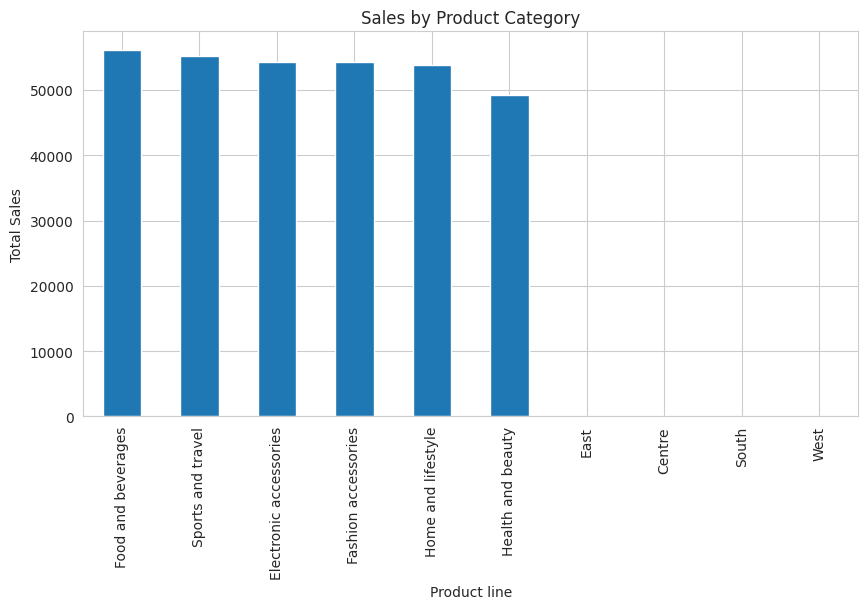

In [27]:
plt.figure(figsize=(10,5))
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
import calendar

df['Month'] = df['Date'].dt.month_name()

# Create an ordered categorical type for months
month_order = [calendar.month_name[i] for i in range(1, 13)]
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales

/tmp/ipykernel_515/2605029292.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month')['Sales'].sum()


,Sales
Month,
January,116291.868
February,97219.374
March,109455.507
April,0.000
May,0.000
June,0.000
July,0.000
August,0.000
September,0.000


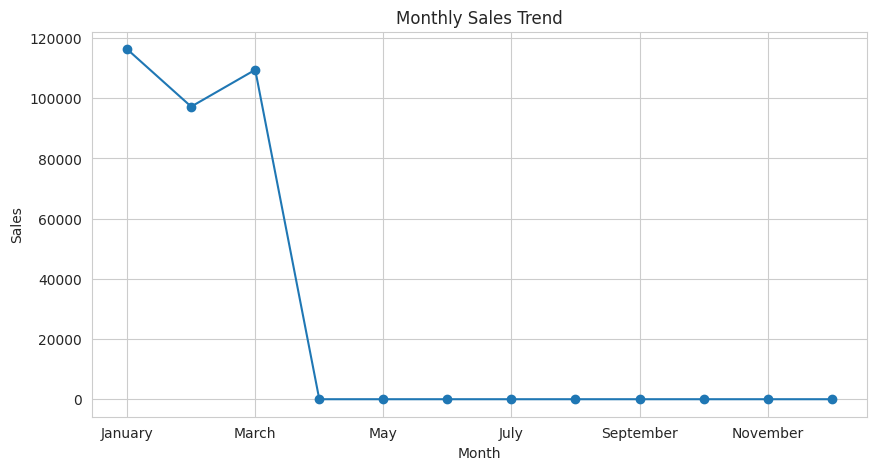

In [ ]:
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

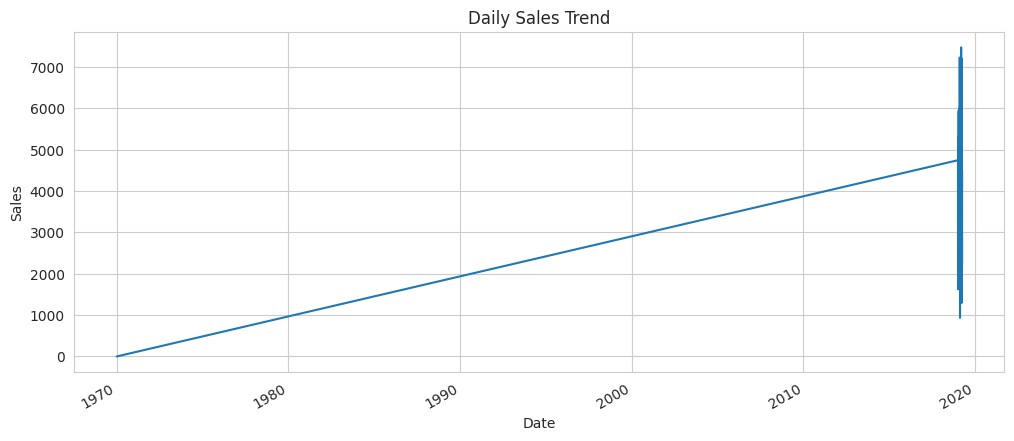

In [ ]:
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.ylabel("Sales")
plt.show()

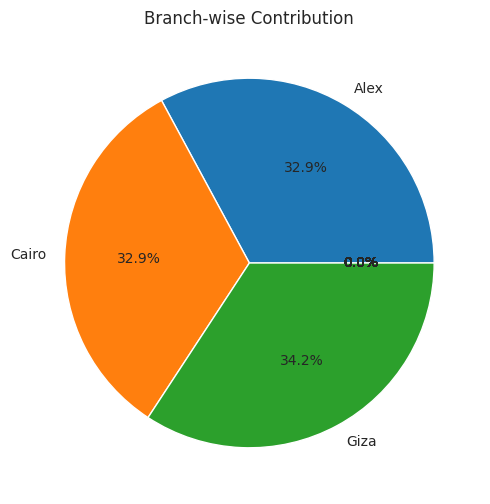

In [11]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
branch_sales = df.groupby('Branch')['Sales'].sum()

plt.figure(figsize=(6,6))
branch_sales.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Branch-wise Contribution")
plt.show()

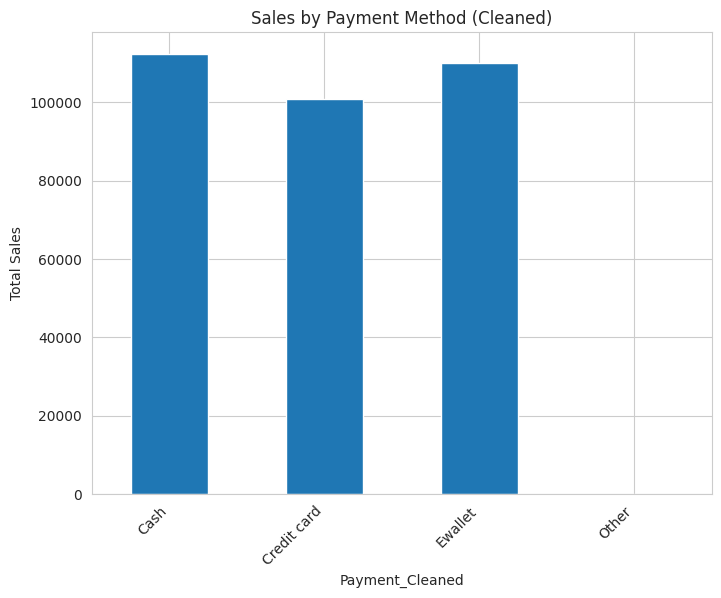

In [18]:
valid_payment_methods = ['Cash', 'Credit card', 'Ewallet']
df['Payment_Cleaned'] = df['Payment'].apply(lambda x: x if x in valid_payment_methods else 'Other')

cleaned_payment_sales = df.groupby('Payment_Cleaned')['Sales'].sum()

plt.figure(figsize=(8, 6))
cleaned_payment_sales.plot(kind='bar')
plt.title('Sales by Payment Method (Cleaned)')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

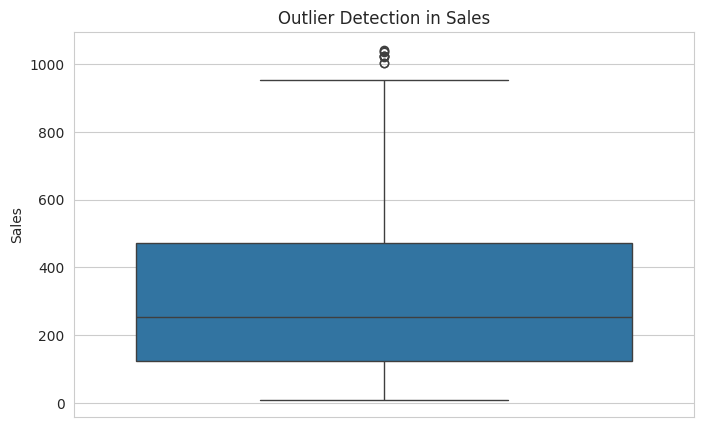

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Sales'])
plt.title("Outlier Detection in Sales")
plt.show()

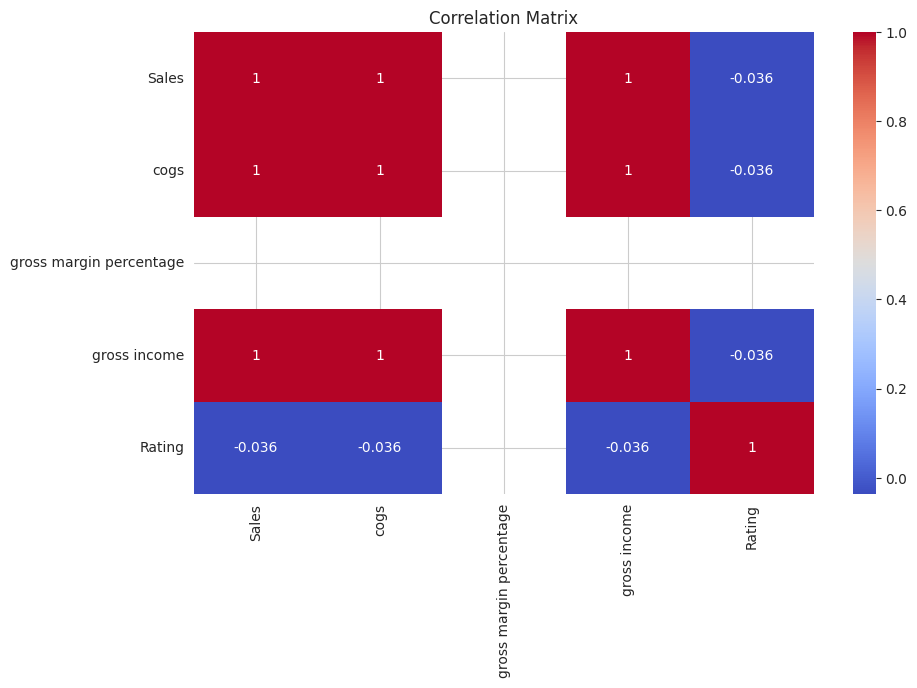

In [22]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Conclusions:

Food and Beverages generated the highest revenue.

Branch A contributed the maximum sales.

E-wallet payments were preferred by customers.

Some transactions were significantly higher than average (outliers).

Sales showed fluctuations across different days and months.